# Proyecto Integrador de Minería de Datos I  
## Notebook 04 — Escalamiento y análisis de componentes principales

**Carrera:** Tecnicatura Superior en Ciencia de Datos e Inteligencia Artificial  
**Asignatura:** Minería de Datos I  
**Dataset utilizado:** `streaming_users_clean.csv`  
**Integrantes:** Thir Ferreyra Nadia Lorena y Constantinidi Leandro Exequiel  
**Comisión:** Turno Tarde  
**Fecha de referencia:** 27 de junio de 2026  

---

## Propósito de esta etapa

En este notebook se aplica Análisis de Componentes Principales (PCA) para estudiar si las variables numéricas contienen información redundante que pueda resumirse mediante una cantidad menor de dimensiones.

La pregunta principal es:

> **¿Cuántos componentes se necesitan para representar la variabilidad de las variables numéricas sin perder una cantidad crítica de información?**

La etapa documenta:

- variables utilizadas y excluidas;
- tratamiento específico de las fechas faltantes;
- necesidad de escalamiento;
- varianza explicada;
- *loadings* o pesos de las variables;
- interpretación y limitaciones.

PCA es una técnica no supervisada. No predice una variable objetivo y no demuestra causalidad.


## 1. Importación de librerías

Se utilizan:

- `pandas` para organizar los datos;
- `numpy` para cálculos numéricos;
- `matplotlib` para las dos visualizaciones;
- `StandardScaler` para estandarizar;
- `PCA` para calcular los componentes principales.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 2. Carga y validación del dataset procesado

Se utiliza exclusivamente el dataset limpio generado en el Notebook 02.  
Se conserva una copia de control para comprobar que esta etapa no modifica el archivo procesado.


In [2]:
rutas_posibles = [
    Path("../data/processed/streaming_users_clean.csv"),
    Path("data/processed/streaming_users_clean.csv"),
    Path("/content/PI_Mineria_Datos_1/data/processed/streaming_users_clean.csv"),
]

ruta_datos = next((ruta for ruta in rutas_posibles if ruta.exists()), None)

if ruta_datos is None:
    raise FileNotFoundError(
        "No se encontró streaming_users_clean.csv en data/processed/."
    )

df = pd.read_csv(
    ruta_datos,
    parse_dates=["last_login_date"],
)

df_control = df.copy(deep=True)

print(f"Archivo cargado desde: {ruta_datos.resolve()}")
print(f"Dimensiones: {df.shape}")
print(f"Usuarios duplicados: {df['user_id'].duplicated().sum()}")
print(f"Nulos por columna:")
display(df.isna().sum().to_frame("cantidad"))

Archivo cargado desde: C:\Proyecto Integrador\PI_Mineria_Datos_1\data\processed\streaming_users_clean.csv
Dimensiones: (8000, 8)
Usuarios duplicados: 0
Nulos por columna:


,cantidad
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,501
customer_support_tickets,0


## 3. Selección de variables

PCA necesita variables numéricas que representen magnitudes comparables después del escalamiento.

### Variables incluidas

| Variable | Qué representa |
|---|---|
| `age` | edad del usuario |
| `monthly_watch_time_mins` | intensidad de consumo mensual |
| `customer_support_tickets` | nivel de contacto con soporte |
| `days_since_last_login` | recencia de actividad |

### Variables excluidas

- `user_id`: es un identificador; su valor numérico no representa una característica.
- `subscription_plan`, `country` y `favorite_genre`: son categóricas. No se codifican porque el objetivo es estudiar las dimensiones numéricas originales y evitar que una codificación arbitraria altere PCA.
- `last_login_date`: no se usa directamente como fecha; se transforma en cantidad de días desde una referencia fija.

La fecha de referencia se fija en **27 de junio de 2026** para que el resultado sea reproducible.


## 4. Preparación de la variable de recencia

### Evidencia

El dataset procesado conserva 501 fechas faltantes porque eran ambiguas, imposibles o futuras y no podían reconstruirse sin adivinar.

Para PCA se consideran dos alternativas:

1. imputar una fecha o cantidad de días;
2. trabajar con los usuarios que tienen una fecha válida.

Imputar la fecha introduciría una actividad que no fue observada. Por eso se evalúa primero la magnitud y distribución de las ausencias.


In [3]:
df_revision = df.copy()
df_revision["fecha_faltante"] = df_revision["last_login_date"].isna()

resumen_faltantes_plan = (
    df_revision
    .groupby("subscription_plan")["fecha_faltante"]
    .agg(["count", "sum", "mean"])
)

resumen_faltantes_plan.columns = [
    "usuarios",
    "fechas_faltantes",
    "proporcion_faltante",
]

resumen_faltantes_plan["porcentaje_faltante"] = (
    resumen_faltantes_plan["proporcion_faltante"] * 100
)

display(resumen_faltantes_plan.round(2))

resumen_faltantes_pais = (
    df_revision
    .groupby("country")["fecha_faltante"]
    .agg(["count", "sum", "mean"])
)

resumen_faltantes_pais.columns = [
    "usuarios",
    "fechas_faltantes",
    "proporcion_faltante",
]

resumen_faltantes_pais["porcentaje_faltante"] = (
    resumen_faltantes_pais["proporcion_faltante"] * 100
)

print("\nAusencia por país:")
display(
    resumen_faltantes_pais
    .sort_values("porcentaje_faltante", ascending=False)
    .round(2)
)

,usuarios,fechas_faltantes,proporcion_faltante,porcentaje_faltante
subscription_plan,,,,
Básico,3600,229,0.0600,6.3600
Estándar,2817,171,0.0600,6.0700
Premium,1583,101,0.0600,6.3800



Ausencia por país:


,usuarios,fechas_faltantes,proporcion_faltante,porcentaje_faltante
country,,,,
México,1156,82,0.0700,7.0900
Chile,1164,77,0.0700,6.6200
Brasil,1156,73,0.0600,6.3100
Uruguay,1143,72,0.0600,6.3000
Perú,1134,69,0.0600,6.0800
Argentina,1105,64,0.0600,5.7900
Colombia,1142,64,0.0600,5.6000


### Interpretación de los faltantes

La tasa de ausencia por plan se mantiene aproximadamente entre 6,1 % y 6,4 %. Entre países varía moderadamente, aproximadamente entre 5,6 % y 7,1 %.

No se puede demostrar que las fechas falten completamente al azar, pero tampoco aparece una concentración extrema en un único plan o país.

### Decisión

Se utiliza un análisis de casos completos:

- usuarios originales: 8.000;
- usuarios con fecha válida: 7.499;
- retención para PCA: 93,74 %.

Esta reducción se aplica únicamente a la matriz de PCA. No se modifica el dataset procesado ni el log ETL, porque no es una nueva limpieza general sino una condición específica de esta técnica.


In [4]:
fecha_referencia = pd.Timestamp("2026-06-27")

df_pca = (
    df.dropna(subset=["last_login_date"])
    .copy()
)

df_pca["days_since_last_login"] = (
    fecha_referencia - df_pca["last_login_date"]
).dt.days

retencion_pca = len(df_pca) / len(df) * 100

print(f"Usuarios originales: {len(df):,}")
print(f"Usuarios utilizados en PCA: {len(df_pca):,}")
print(f"Usuarios excluidos por fecha faltante: {len(df) - len(df_pca):,}")
print(f"Retención para PCA: {retencion_pca:.2f}%")

print("\nRango de days_since_last_login:")
print(
    f"{df_pca['days_since_last_login'].min()} a "
    f"{df_pca['days_since_last_login'].max()} días"
)

Usuarios originales: 8,000
Usuarios utilizados en PCA: 7,499
Usuarios excluidos por fecha faltante: 501
Retención para PCA: 93.74%

Rango de days_since_last_login:
178 a 3099 días


## 5. Matriz numérica utilizada

La matriz `X` contiene cuatro variables y 7.499 usuarios.

Antes de escalar se revisan sus estadísticas y correlaciones.


In [5]:
variables_pca = [
    "age",
    "monthly_watch_time_mins",
    "customer_support_tickets",
    "days_since_last_login",
]

X = df_pca[variables_pca].copy()

display(X.describe().T)

print("\nMatriz de correlaciones:")
matriz_correlaciones = X.corr()
display(matriz_correlaciones.round(4))

,count,mean,std,min,25%,50%,75%,max
age,"7,499.0000",33.6744,11.4680,13.0000,26.0000,33.0000,41.0000,80.0000
monthly_watch_time_mins,"7,499.0000",802.2994,492.3251,0.0000,500.9000,770.8000,"1,058.4500","4,193.7000"
customer_support_tickets,"7,499.0000",0.7429,0.8538,0.0000,0.0000,1.0000,1.0000,5.0000
days_since_last_login,"7,499.0000","1,607.5003",846.3044,178.0000,862.5000,"1,594.0000","2,350.0000","3,099.0000"



Matriz de correlaciones:


,age,monthly_watch_time_mins,customer_support_tickets,days_since_last_login
age,1.0000,0.0067,0.0058,-0.0112
monthly_watch_time_mins,0.0067,1.0000,0.0019,-0.0064
customer_support_tickets,0.0058,0.0019,1.0000,0.0007
days_since_last_login,-0.0112,-0.0064,0.0007,1.0000


### Interpretación de las correlaciones

Las correlaciones lineales entre las cuatro variables son muy pequeñas. Esto anticipa que PCA probablemente no encontrará una dirección que concentre una proporción muy elevada de la variabilidad.

PCA puede aplicarse igualmente, pero el resultado debe utilizarse para evaluar la redundancia, no para forzar una reducción.


# 6. Justificación del escalamiento

## 6.1 Escalas originales

Las variables utilizan unidades y rangos muy diferentes:

- edad: años;
- consumo: minutos;
- soporte: cantidad de tickets;
- recencia: días.

PCA busca las direcciones de mayor varianza. Sin escalamiento, una variable puede dominar solamente porque sus números son más grandes.


In [6]:
varianzas_originales = (
    X.var()
    .rename("varianza_original")
    .to_frame()
)

display(varianzas_originales)

,varianza_original
age,131.5157
monthly_watch_time_mins,"242,384.0302"
customer_support_tickets,0.7290
days_since_last_login,"716,231.0764"


## 6.2 Qué ocurriría sin escalar

Se ejecuta PCA sin escalamiento solamente como diagnóstico. Este resultado no será el utilizado para las conclusiones.


In [7]:
pca_sin_escalar = PCA()
pca_sin_escalar.fit(X)

resultado_sin_escalar = pd.DataFrame({
    "componente": [
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ],
    "varianza_explicada_pct": (
        pca_sin_escalar.explained_variance_ratio_ * 100
    ),
    "varianza_acumulada_pct": (
        np.cumsum(
            pca_sin_escalar.explained_variance_ratio_
        ) * 100
    ),
})

display(resultado_sin_escalar.round(4))

loadings_sin_escalar = pd.DataFrame(
    pca_sin_escalar.components_.T,
    index=variables_pca,
    columns=[
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ],
)

print("\nLoadings sin escalar:")
display(loadings_sin_escalar.round(4))

,componente,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,74.7064,74.7064
1,PC2,25.2798,99.9862
2,PC3,0.0137,99.9999
3,PC4,0.0001,100.0000



Loadings sin escalar:


,PC1,PC2,PC3,PC4
age,-0.0002,0.0002,1.0000,-0.0004
monthly_watch_time_mins,-0.0056,1.0000,-0.0002,-0.0000
customer_support_tickets,0.0000,0.0000,0.0004,1.0000
days_since_last_login,1.0000,0.0056,0.0002,-0.0000


### Interpretación

Sin escalar:

- PC1 explica cerca del 74,7 % y está dominado casi completamente por `days_since_last_login`;
- PC2 explica cerca del 25,3 % y está dominado por `monthly_watch_time_mins`;
- edad y tickets prácticamente desaparecen de los primeros componentes.

Esto no demuestra que recencia y consumo sean conceptualmente más importantes. Refleja que sus varianzas numéricas son mucho mayores.

Por esa razón, el PCA sin escalar se descarta.


## 6.3 Estandarización Z-score

Se utiliza `StandardScaler`:

\[
z = 
rac{x - \mu}{\sigma}
\]

Después de la transformación, cada variable queda aproximadamente con:

- media 0;
- desviación estándar 1;
- varianza 1.

Así, ninguna variable domina por sus unidades originales.


In [8]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=variables_pca,
    index=X.index,
)

comparacion_escalas = pd.DataFrame({
    "media_original": X.mean(),
    "desviacion_original": X.std(ddof=0),
    "media_estandarizada": X_scaled.mean(),
    "desviacion_estandarizada": X_scaled.std(ddof=0),
    "varianza_estandarizada": X_scaled.var(ddof=0),
})

display(comparacion_escalas.round(4))

,media_original,desviacion_original,media_estandarizada,desviacion_estandarizada,varianza_estandarizada
age,33.6744,11.4673,-0.0000,1.0000,1.0000
monthly_watch_time_mins,802.2994,492.2923,0.0000,1.0000,1.0000
customer_support_tickets,0.7429,0.8538,0.0000,1.0000,1.0000
days_since_last_login,"1,607.5003",846.2479,-0.0000,1.0000,1.0000


### Decisión

El análisis definitivo se realiza con `X_scaled`.

La estandarización no cambia el orden relativo de los usuarios dentro de cada variable. Cambia la unidad de medida para que todas contribuyan en condiciones comparables.


# 7. PCA sobre todas las componentes

Con cuatro variables existen como máximo cuatro componentes.

Primero se ajustan todos para observar cuánta varianza explica cada uno. No se elige una cantidad de componentes de antemano.


In [9]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

tabla_varianza = pd.DataFrame({
    "componente": [
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ],
    "varianza_explicada": (
        pca_full.explained_variance_ratio_
    ),
    "varianza_explicada_pct": (
        pca_full.explained_variance_ratio_ * 100
    ),
    "varianza_acumulada_pct": (
        np.cumsum(
            pca_full.explained_variance_ratio_
        ) * 100
    ),
})

display(tabla_varianza.round(4))

,componente,varianza_explicada,varianza_explicada_pct,varianza_acumulada_pct
0,PC1,0.2543,25.4342,25.4342
1,PC2,0.2502,25.0171,50.4512
2,PC3,0.2487,24.8707,75.3219
3,PC4,0.2468,24.6781,100.0000


## Visualización 1 — Varianza explicada y acumulada

Las barras muestran el aporte individual de cada componente.  
La línea muestra la información total acumulada al agregar componentes.


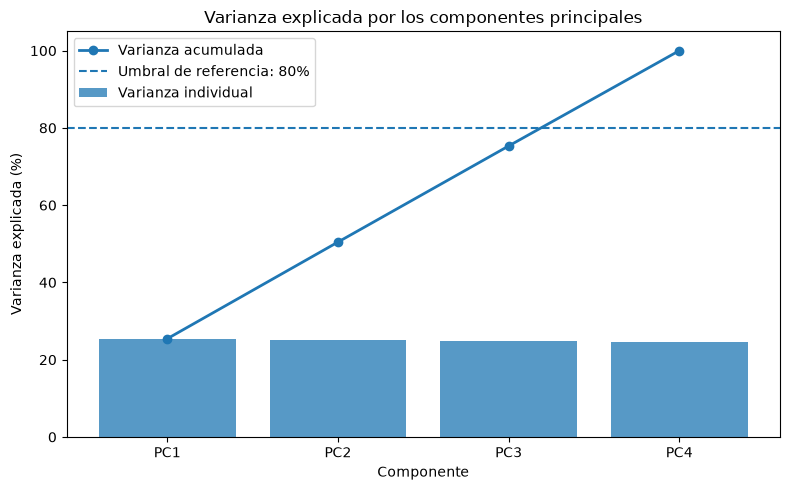

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

componentes = tabla_varianza["componente"]
varianza_individual = tabla_varianza["varianza_explicada_pct"]
varianza_acumulada = tabla_varianza["varianza_acumulada_pct"]

ax.bar(
    componentes,
    varianza_individual,
    alpha=0.75,
    label="Varianza individual",
)

ax.plot(
    componentes,
    varianza_acumulada,
    marker="o",
    linewidth=2,
    label="Varianza acumulada",
)

ax.axhline(
    80,
    linestyle="--",
    linewidth=1.5,
    label="Umbral de referencia: 80%",
)

ax.set_title("Varianza explicada por los componentes principales")
ax.set_xlabel("Componente")
ax.set_ylabel("Varianza explicada (%)")
ax.set_ylim(0, 105)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la varianza explicada

Los resultados son aproximadamente:

- PC1: 25,43 %;
- PC2: 25,02 %;
- PC3: 24,87 %;
- PC4: 24,68 %.

La varianza está distribuida de manera casi uniforme.

- dos componentes retienen 50,45 %;
- tres componentes retienen 75,32 %;
- para superar el umbral de referencia del 80 % se necesitan los cuatro componentes.

### Decisión sobre la reducción

PCA no ofrece una reducción dimensional eficiente para estas cuatro variables.

Reducir de cuatro a dos dimensiones perdería aproximadamente la mitad de la variabilidad. Reducir a tres todavía perdería cerca del 24,7 %. Por ello:

> Los dos primeros componentes se utilizarán para visualización exploratoria, pero no se recomendará reemplazar las cuatro variables originales por solamente dos componentes.


# 8. Loadings e interpretación de componentes

Los *loadings* son los pesos de cada variable original dentro de cada componente.

- un valor absoluto grande indica mayor contribución;
- variables con el mismo signo se orientan en el mismo sentido;
- variables con signos opuestos se contraponen dentro del componente.

El signo global de un componente puede invertirse sin cambiar la solución matemática. Por eso importa la relación entre los pesos, no considerar que un signo positivo sea universalmente “bueno”.


In [11]:
loadings = pd.DataFrame(
    pca_full.components_.T,
    index=variables_pca,
    columns=[
        f"PC{i + 1}"
        for i in range(len(variables_pca))
    ],
)

display(loadings.round(4))

print("\nVariables ordenadas por contribución absoluta en PC1:")
display(
    loadings["PC1"]
    .abs()
    .sort_values(ascending=False)
    .rename("contribucion_absoluta")
    .to_frame()
)

print("\nVariables ordenadas por contribución absoluta en PC2:")
display(
    loadings["PC2"]
    .abs()
    .sort_values(ascending=False)
    .rename("contribucion_absoluta")
    .to_frame()
)

,PC1,PC2,PC3,PC4
age,0.6277,0.1010,-0.3269,0.6993
monthly_watch_time_mins,0.4749,-0.1228,0.8714,-0.0012
customer_support_tickets,0.2406,0.9058,-0.0040,-0.3486
days_since_last_login,-0.5680,0.3927,0.3657,0.6241



Variables ordenadas por contribución absoluta en PC1:


,contribucion_absoluta
age,0.6277
days_since_last_login,0.5680
monthly_watch_time_mins,0.4749
customer_support_tickets,0.2406



Variables ordenadas por contribución absoluta en PC2:


,contribucion_absoluta
customer_support_tickets,0.9058
days_since_last_login,0.3927
monthly_watch_time_mins,0.1228
age,0.1010


## Interpretación tentativa de PC1

PC1 recibe sus mayores aportes de:

- edad: positivo;
- días desde el último ingreso: negativo;
- tiempo mensual: positivo.

Dentro de la orientación obtenida, valores altos de PC1 tienden a combinar mayor edad y consumo con una fecha de ingreso más reciente, porque una menor cantidad de días tiene peso negativo.

Este eje puede describirse tentativamente como una combinación de **consumo y recencia**, acompañada por la edad. No debe interpretarse como una característica universal de los usuarios.

## Interpretación tentativa de PC2

PC2 está dominado por la cantidad de tickets de soporte, con una contribución secundaria de los días desde el último ingreso.

Puede describirse tentativamente como una dimensión de **contacto con soporte**, relacionada en menor medida con la recencia.

## Precaución

Ninguno de los componentes explica por sí solo una proporción alta de la varianza. Por eso sus interpretaciones son menos compactas que en un dataset con variables fuertemente correlacionadas.


# 9. Contribución de las variables en PC1 y PC2

Para comunicar el resultado de PCA de una manera más clara, se analiza cuánto aporta cada variable original a las dos primeras componentes.

La contribución se obtiene elevando al cuadrado los *loadings* de cada variable. De esta forma:

- todos los aportes quedan expresados como porcentajes positivos;
- las contribuciones suman 100 % dentro de cada componente;
- una barra más larga indica una mayor participación en la construcción de la componente.

Esta visualización permite comprender qué información resume PC1 y qué información resume PC2, sin mostrar miles de usuarios superpuestos.

Contribución porcentual de las variables:


,PC1,PC2
Edad,39.4000,1.0200
Minutos mensuales,22.5600,1.5100
Tickets de soporte,5.7900,82.0500
Días desde el último ingreso,32.2600,15.4200


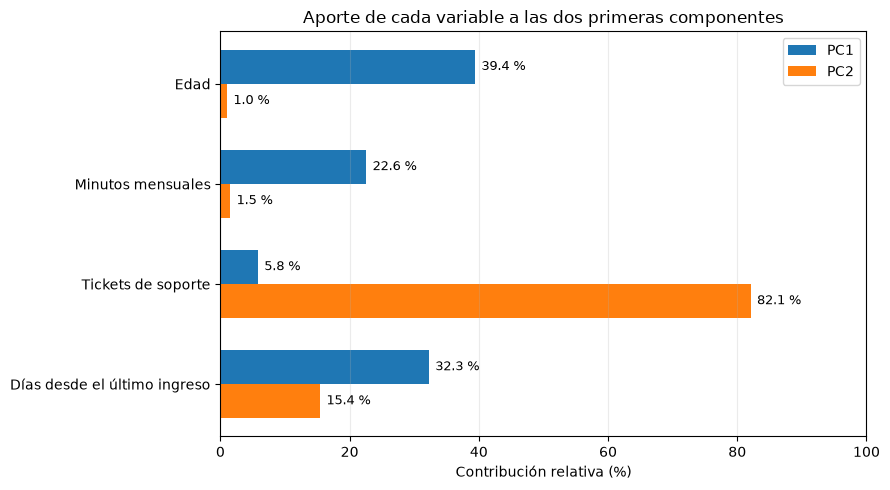

In [12]:
contribuciones = (
    loadings[["PC1", "PC2"]].pow(2) * 100
)

nombres_variables = {
    "age": "Edad",
    "monthly_watch_time_mins": "Minutos mensuales",
    "customer_support_tickets": "Tickets de soporte",
    "days_since_last_login": "Días desde el último ingreso",
}

aportes = contribuciones.rename(
    index=nombres_variables
)

print("Contribución porcentual de las variables:")
display(aportes.round(2))

y = np.arange(len(aportes))
alto = 0.34

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    y - alto / 2,
    aportes["PC1"],
    height=alto,
    label="PC1",
)

ax.barh(
    y + alto / 2,
    aportes["PC2"],
    height=alto,
    label="PC2",
)

ax.set_yticks(y)
ax.set_yticklabels(aportes.index)
ax.invert_yaxis()

ax.set_xlim(0, 100)
ax.set_xlabel("Contribución relativa (%)")

ax.set_title(
    "Aporte de cada variable a las dos primeras componentes"
)

ax.legend()
ax.grid(axis="x", alpha=0.25)

for indice, valor in enumerate(aportes["PC1"]):
    ax.text(
        valor + 1,
        indice - alto / 2,
        f"{valor:.1f} %",
        va="center",
        fontsize=9,
    )

for indice, valor in enumerate(aportes["PC2"]):
    ax.text(
        valor + 1,
        indice + alto / 2,
        f"{valor:.1f} %",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
display(fig)
plt.close(fig)

### Interpretación de las contribuciones

PC1 combina principalmente:

* edad: 39,4 %;
* días desde el último ingreso: 32,3 %;
* minutos mensuales: 22,6 %.

Los tickets de soporte tienen una participación menor en esta componente, con 5,8 %. Por lo tanto, PC1 resume principalmente una combinación de edad, nivel de consumo y recencia de actividad.

PC2 está dominada por los tickets de soporte, con una contribución del 82,1 %. Los días desde el último ingreso aportan un 15,4 %, mientras que la edad y los minutos mensuales tienen participaciones muy pequeñas.

Esto permite interpretar PC2 principalmente como una dimensión relacionada con el contacto de los usuarios con el servicio de soporte.

Las dos componentes están formadas por variables diferentes. Esta evidencia ayuda a explicar por qué PCA no logra resumir eficientemente las cuatro variables originales utilizando solamente dos componentes.


# 10. Respuesta a la pregunta de PCA

## Evidencia

- Las correlaciones entre las variables son muy bajas.
- Cada componente explica aproximadamente una cuarta parte de la variabilidad.
- Se necesitan cuatro componentes para superar el 80 % de varianza acumulada.
- PC1 combina principalmente edad, recencia y minutos mensuales.
- PC2 está dominada por los tickets de soporte.
- Las variables aportan dimensiones relativamente diferentes.

## Interpretación

La información de edad, consumo, soporte y recencia no es fuertemente redundante. Cada variable aporta una dimensión relativamente diferente del comportamiento de los usuarios.

El análisis de contribuciones permite comprender qué variables forman las dos primeras componentes, pero estas componentes explican solamente el 50,45 % de la variabilidad total.

## Conclusión

> PCA no permite reducir estas cuatro variables a dos o tres componentes sin una pérdida importante de información.

Este resultado no significa que la técnica haya fallado. PCA cumplió su propósito al demostrar que la estructura numérica está distribuida entre varias dimensiones y que conservar las variables originales resulta más interpretable para este proyecto.

# 11. Limitaciones específicas de PCA

1. El análisis utiliza 7.499 usuarios con fecha válida y excluye 501 casos.
2. La variable de recencia depende de una fecha de referencia fija.
3. `StandardScaler` es sensible a valores extremos, aunque los errores imposibles ya fueron tratados y los valores altos plausibles se conservaron.
4. PCA captura relaciones lineales; no resume estructuras no lineales.
5. Las componentes son combinaciones matemáticas y pueden ser menos fáciles de comunicar que las variables originales.
6. El signo de los *loadings* puede invertirse sin alterar la solución.
7. Las dos primeras componentes explican solamente el 50,45 % de la variabilidad, por lo que no representan toda la información de las cuatro variables originales.
8. El gráfico de contribuciones explica cómo se forman PC1 y PC2, pero no muestra el comportamiento individual de cada usuario.

# 12. Decisión para Streamlit

La página `03_PCA.py` presenta un máximo de dos visualizaciones:

1. varianza explicada y acumulada;
2. contribución de las variables a PC1 y PC2.

También muestra:

- las cuatro variables utilizadas;
- el uso de `StandardScaler`;
- la retención de casos;
- la interpretación de las contribuciones;
- la conclusión de que no existe una reducción eficiente.

La segunda visualización reemplaza la proyección de miles de usuarios por un gráfico más claro para público general.

La página no presenta PCA como una técnica que necesariamente debe producir pocos componentes. Se comunica el resultado real obtenido.

# 13. Verificación de integridad

Se comprueba que el dataset procesado no fue modificado. Las columnas auxiliares y la matriz de PCA se crearon en copias independientes.


In [13]:
dataset_sin_modificaciones = df.equals(df_control)

controles_finales = {
    "Dataset procesado sin modificaciones": dataset_sin_modificaciones,
    "Matriz PCA sin valores faltantes": int(X.isna().sum().sum()) == 0,
    "Cuatro variables utilizadas": X.shape[1] == 4,
    "7.499 usuarios utilizados": X.shape[0] == 7499,
    "Varianza acumulada final igual a 100%": np.isclose(
        tabla_varianza["varianza_acumulada_pct"].iloc[-1],
        100.0,
    ),
}

tabla_controles = pd.DataFrame({
    "control": list(controles_finales.keys()),
    "resultado": list(controles_finales.values()),
})

display(tabla_controles)

if not all(controles_finales.values()):
    fallidos = [
        nombre
        for nombre, resultado in controles_finales.items()
        if not resultado
    ]
    raise AssertionError(
        f"Fallaron los controles: {fallidos}"
    )

print("Todos los controles fueron superados.")

,control,resultado
0,Dataset procesado sin modificaciones,True
1,Matriz PCA sin valores faltantes,True
2,Cuatro variables utilizadas,True
3,7.499 usuarios utilizados,True
4,Varianza acumulada final igual a 100%,True


Todos los controles fueron superados.
